In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,5)



df = pd.read_excel('Sales_Forcasting_Dataset.xlsx')
print('Shape:', df.shape)
df.head()


Shape: (3000, 27)


,Row_ID,Date,Product_ID,Product_Name,Category,Store_ID,Store_Location,Units_Sold,Price,Discount_Percentage,...,Holiday_Name,Is_Weekend,Season,Weather,Local_Event_Flag,Competitor_Price,Economic_Indicator,Sales_Channel,Customer_Segment,Marketing_Spend
0,1,2023-01-06,P002,Bluetooth Speaker,Electronics,S01,Chennai,54,3763.742294,0,...,New Year,0,Winter,Sunny,1,3454.023813,100.942142,Online,Retail,0.000000
1,2,2023-01-13,P002,Bluetooth Speaker,Electronics,S01,Chennai,58,3763.712176,0,...,New Year,0,Winter,Sunny,1,3446.529758,100.941796,Online,Retail,0.000000
2,3,2023-01-28,P002,Bluetooth Speaker,Electronics,S01,Chennai,64,2398.777773,8,...,NaN,0,Winter,Sunny,1,2266.365488,98.543457,In-Store,Retail,8410.202040
3,4,2023-02-09,P005,LED Desk Lamp,Home,S04,Delhi,96,1406.019435,20,...,NaN,1,Winter,Sunny,0,1493.410240,95.786449,In-Store,Retail,6880.514325
4,5,2023-02-13,P006,Running Shoes,Apparel,S02,Bengaluru,45,3337.215178,6,...,NaN,0,Winter,Rainy,0,3100.272443,106.214774,Wholesale,Corporate,7908.876991


In [2]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 27 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Row_ID               3000 non-null   int64  
 1   Date                 3000 non-null   object 
 2   Product_ID           3000 non-null   object 
 3   Product_Name         3000 non-null   object 
 4   Category             3000 non-null   object 
 5   Store_ID             3000 non-null   object 
 6   Store_Location       3000 non-null   object 
 7   Units_Sold           3000 non-null   int64  
 8   Price                3000 non-null   float64
 9   Discount_Percentage  3000 non-null   int64  
 10  Revenue              3000 non-null   float64
 11  Promotion_Flag       3000 non-null   int64  
 12  Stock_Availability   3000 non-null   int64  
 13  Day_of_Week          3000 non-null   object 
 14  Month                3000 non-null   object 
 15  Quarter              3000 non-null   o

In [3]:
print('Columns:', list(df.columns))
print('Total rows:', df.shape[0], '| Total cols:', df.shape[1])


Columns: ['Row_ID', 'Date', 'Product_ID', 'Product_Name', 'Category', 'Store_ID', 'Store_Location', 'Units_Sold', 'Price', 'Discount_Percentage', 'Revenue', 'Promotion_Flag', 'Stock_Availability', 'Day_of_Week', 'Month', 'Quarter', 'Holiday_Flag', 'Holiday_Name', 'Is_Weekend', 'Season', 'Weather', 'Local_Event_Flag', 'Competitor_Price', 'Economic_Indicator', 'Sales_Channel', 'Customer_Segment', 'Marketing_Spend']
Total rows: 3000 | Total cols: 27


In [4]:
dup_full = df.duplicated().sum()
dup_excl_id = df.drop(columns=['Row_ID']).duplicated().sum()
print('Exact duplicate rows:', dup_full)
print('Duplicate rows (ignoring Row_ID):', dup_excl_id)

if dup_excl_id > 0:
    df = df.drop_duplicates(subset=df.columns.difference(['Row_ID']))
    print('Dropped duplicates. New shape:', df.shape)
else:
    print('No duplicates found. Dataset is clean!')


Exact duplicate rows: 0
Duplicate rows (ignoring Row_ID): 0
No duplicates found. Dataset is clean!


In [5]:
df['Date'] = pd.to_datetime(df['Date'])


actual_day = df['Date'].dt.day_name()
mismatch_count = (df['Day_of_Week'] != actual_day).sum()
print(f'Mismatch rows: {mismatch_count} out of {len(df)}')


df['Day_of_Week'] = actual_day
print('Day_of_Week fixed using actual Date. Sample:')
df[['Date','Day_of_Week']].head()


Mismatch rows: 1961 out of 3000
Day_of_Week fixed using actual Date. Sample:


,Date,Day_of_Week
0,2023-01-06,Friday
1,2023-01-13,Friday
2,2023-01-28,Saturday
3,2023-02-09,Thursday
4,2023-02-13,Monday


In [6]:

cat_like = ['Product_ID','Product_Name','Category','Store_ID','Store_Location','Day_of_Week',
            'Month','Quarter','Holiday_Name','Season','Weather','Sales_Channel','Customer_Segment']
for c in cat_like:
    df[c] = df[c].astype('category')

flag_cols = ['Promotion_Flag','Stock_Availability','Holiday_Flag','Is_Weekend','Local_Event_Flag']
for c in flag_cols:
    df[c] = df[c].astype(int)


for c in ['Units_Sold','Price','Revenue','Marketing_Spend','Competitor_Price']:
    neg = (df[c] < 0).sum()
    if neg > 0:
        print(f' {c} has {neg} negative values — please check!')
print('Type treatment done. Anomaly check clean.')
df.dtypes


Type treatment done. Anomaly check clean.


,0
Row_ID,int64
Date,datetime64[ns]
Product_ID,category
Product_Name,category
Category,category
Store_ID,category
Store_Location,category
Units_Sold,int64
Price,float64
Discount_Percentage,int64


In [7]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['category']).columns.tolist()


if 'Row_ID' in numeric_cols:
    numeric_cols.remove('Row_ID')

print('Numeric columns (', len(numeric_cols), '):', numeric_cols)
print()
print('Categorical columns (', len(categorical_cols), '):', categorical_cols)


Numeric columns ( 12 ): ['Units_Sold', 'Price', 'Discount_Percentage', 'Revenue', 'Promotion_Flag', 'Stock_Availability', 'Holiday_Flag', 'Is_Weekend', 'Local_Event_Flag', 'Competitor_Price', 'Economic_Indicator', 'Marketing_Spend']

Categorical columns ( 13 ): ['Product_ID', 'Product_Name', 'Category', 'Store_ID', 'Store_Location', 'Day_of_Week', 'Month', 'Quarter', 'Holiday_Name', 'Season', 'Weather', 'Sales_Channel', 'Customer_Segment']


In [8]:
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Units_Sold,3000.0,42.068667,29.250319,0.000000,15.000000,43.000000,64.000000,121.000000
Price,3000.0,2573.711019,1395.352185,201.882929,1291.656025,2548.635583,3773.608720,4995.614847
Discount_Percentage,3000.0,7.901333,7.542274,0.000000,0.000000,5.000000,15.000000,24.000000
Revenue,3000.0,93319.937417,76773.465037,0.000000,27256.148309,76743.467678,147541.800000,328186.009983
Promotion_Flag,3000.0,0.713000,0.452437,0.000000,0.000000,1.000000,1.000000,1.000000
Stock_Availability,3000.0,0.782000,0.412956,0.000000,1.000000,1.000000,1.000000,1.000000
Holiday_Flag,3000.0,0.010333,0.101143,0.000000,0.000000,0.000000,0.000000,1.000000
Is_Weekend,3000.0,0.295000,0.456119,0.000000,0.000000,0.000000,1.000000,1.000000
Local_Event_Flag,3000.0,0.219333,0.413864,0.000000,0.000000,0.000000,0.000000,1.000000
Competitor_Price,3000.0,2576.519046,1409.036602,178.622136,1294.086406,2551.171348,3747.301655,5321.850000


In [9]:
df[categorical_cols].describe().T


,count,unique,top,freq
Product_ID,3000,8,P005,408
Product_Name,3000,8,LED Desk Lamp,408
Category,3000,7,Electronics,688
Store_ID,3000,4,S01,833
Store_Location,3000,4,Chennai,833
Day_of_Week,3000,7,Saturday,479
Month,3000,12,June,267
Quarter,3000,4,Q1,773
Holiday_Name,31,7,Republic Day,8
Season,3000,4,Summer,771


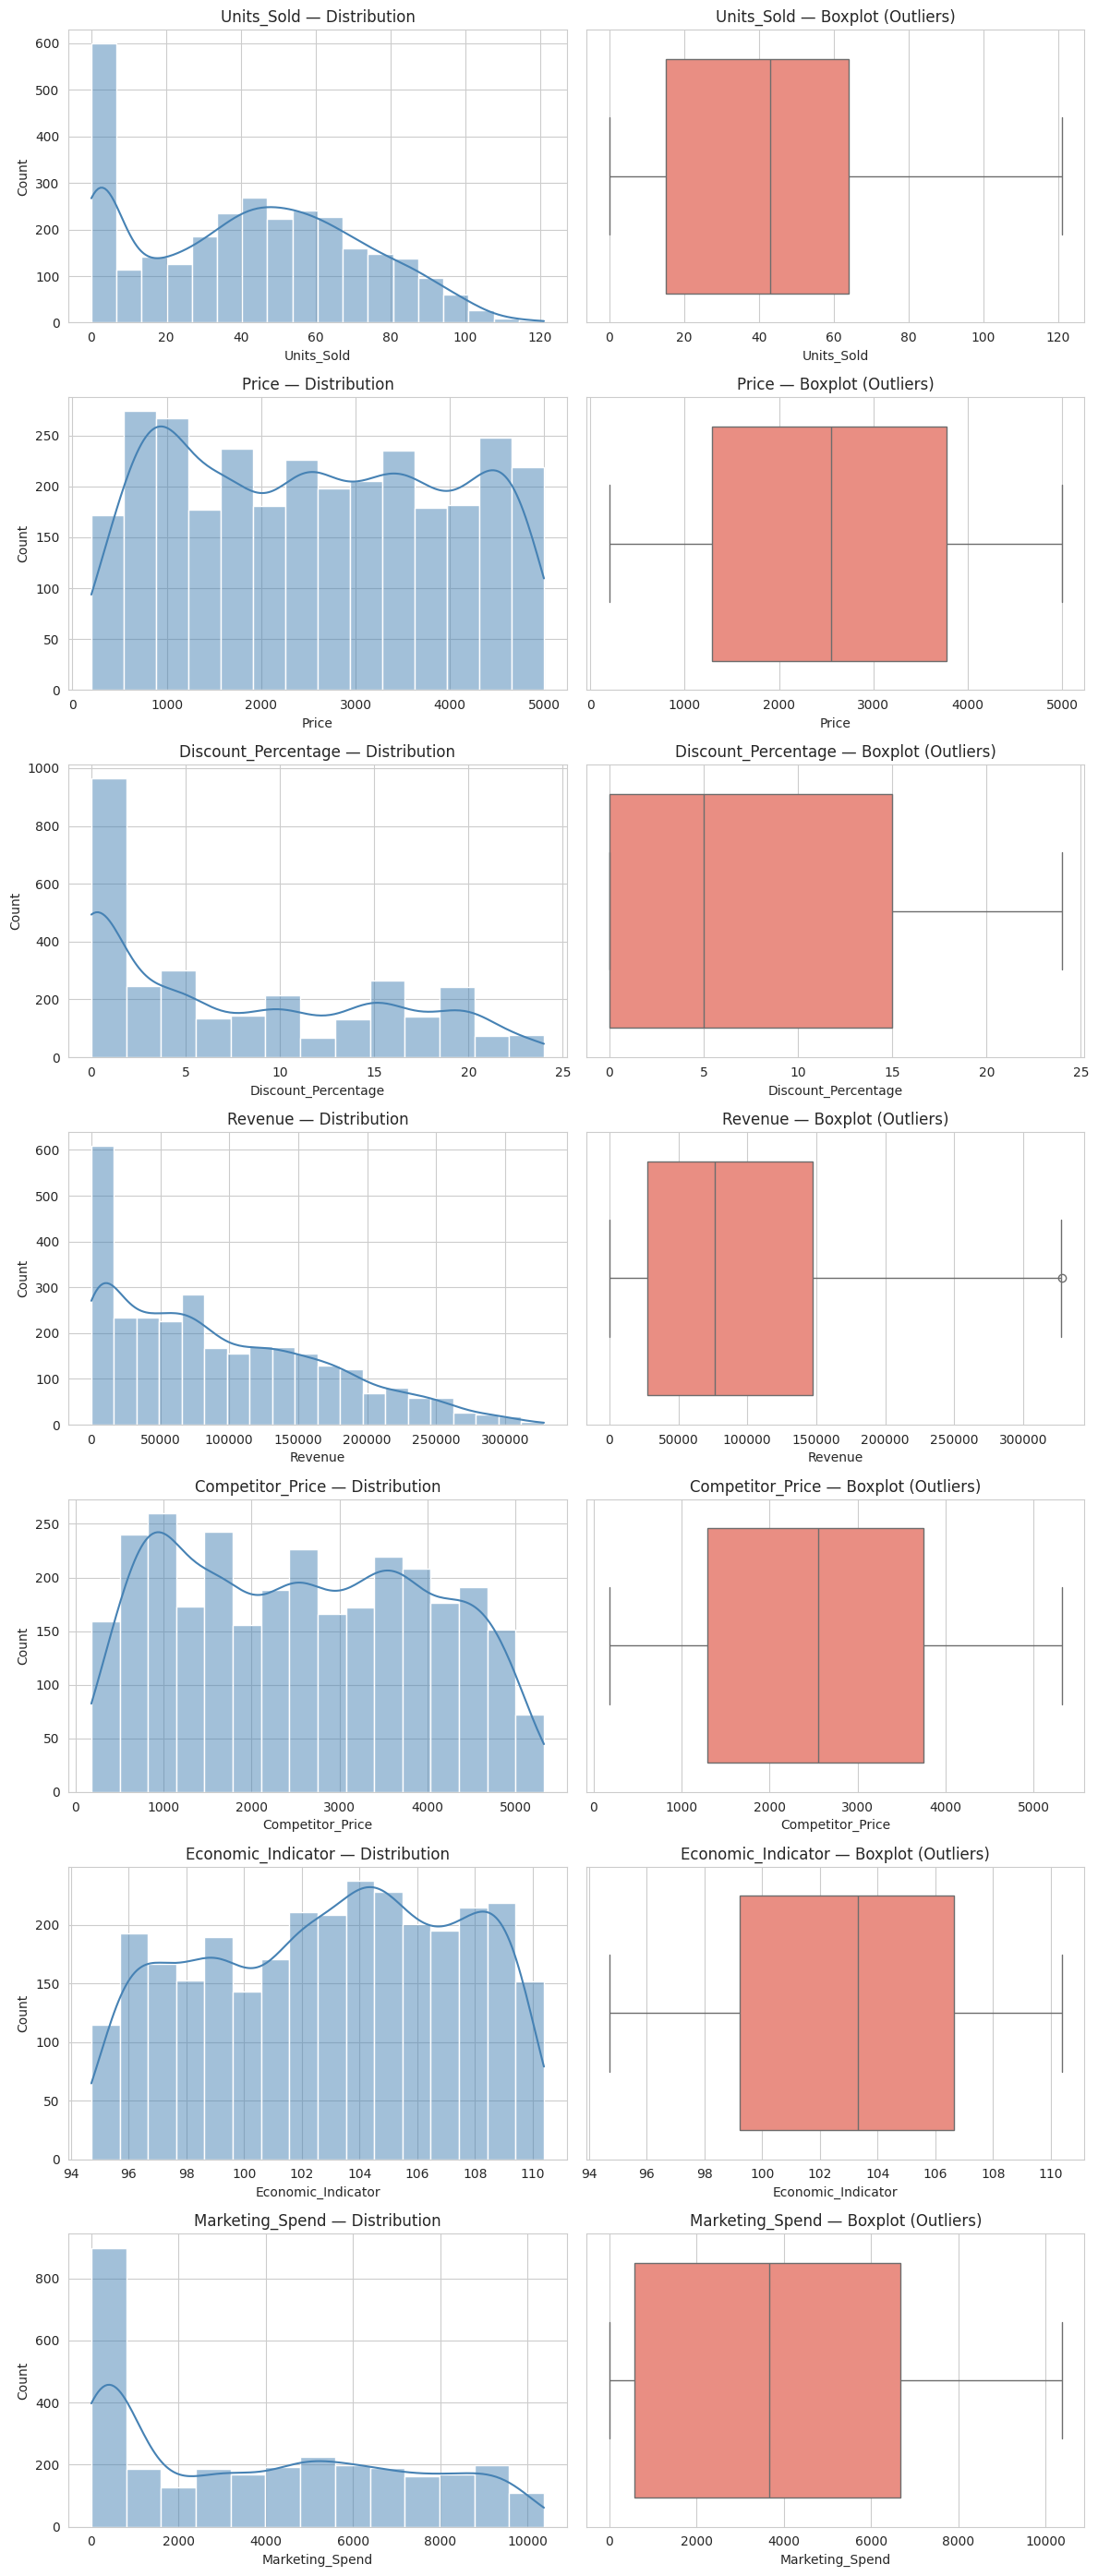

In [10]:
key_numeric = ['Units_Sold','Price','Discount_Percentage','Revenue','Competitor_Price',
               'Economic_Indicator','Marketing_Spend']

fig, axes = plt.subplots(len(key_numeric), 2, figsize=(12, 4*len(key_numeric)))
for i, col in enumerate(key_numeric):
    sns.histplot(df[col], kde=True, ax=axes[i,0], color='steelblue')
    axes[i,0].set_title(f'{col} — Distribution')
    sns.boxplot(x=df[col], ax=axes[i,1], color='salmon')
    axes[i,1].set_title(f'{col} — Boxplot (Outliers)')
plt.tight_layout()
plt.show()


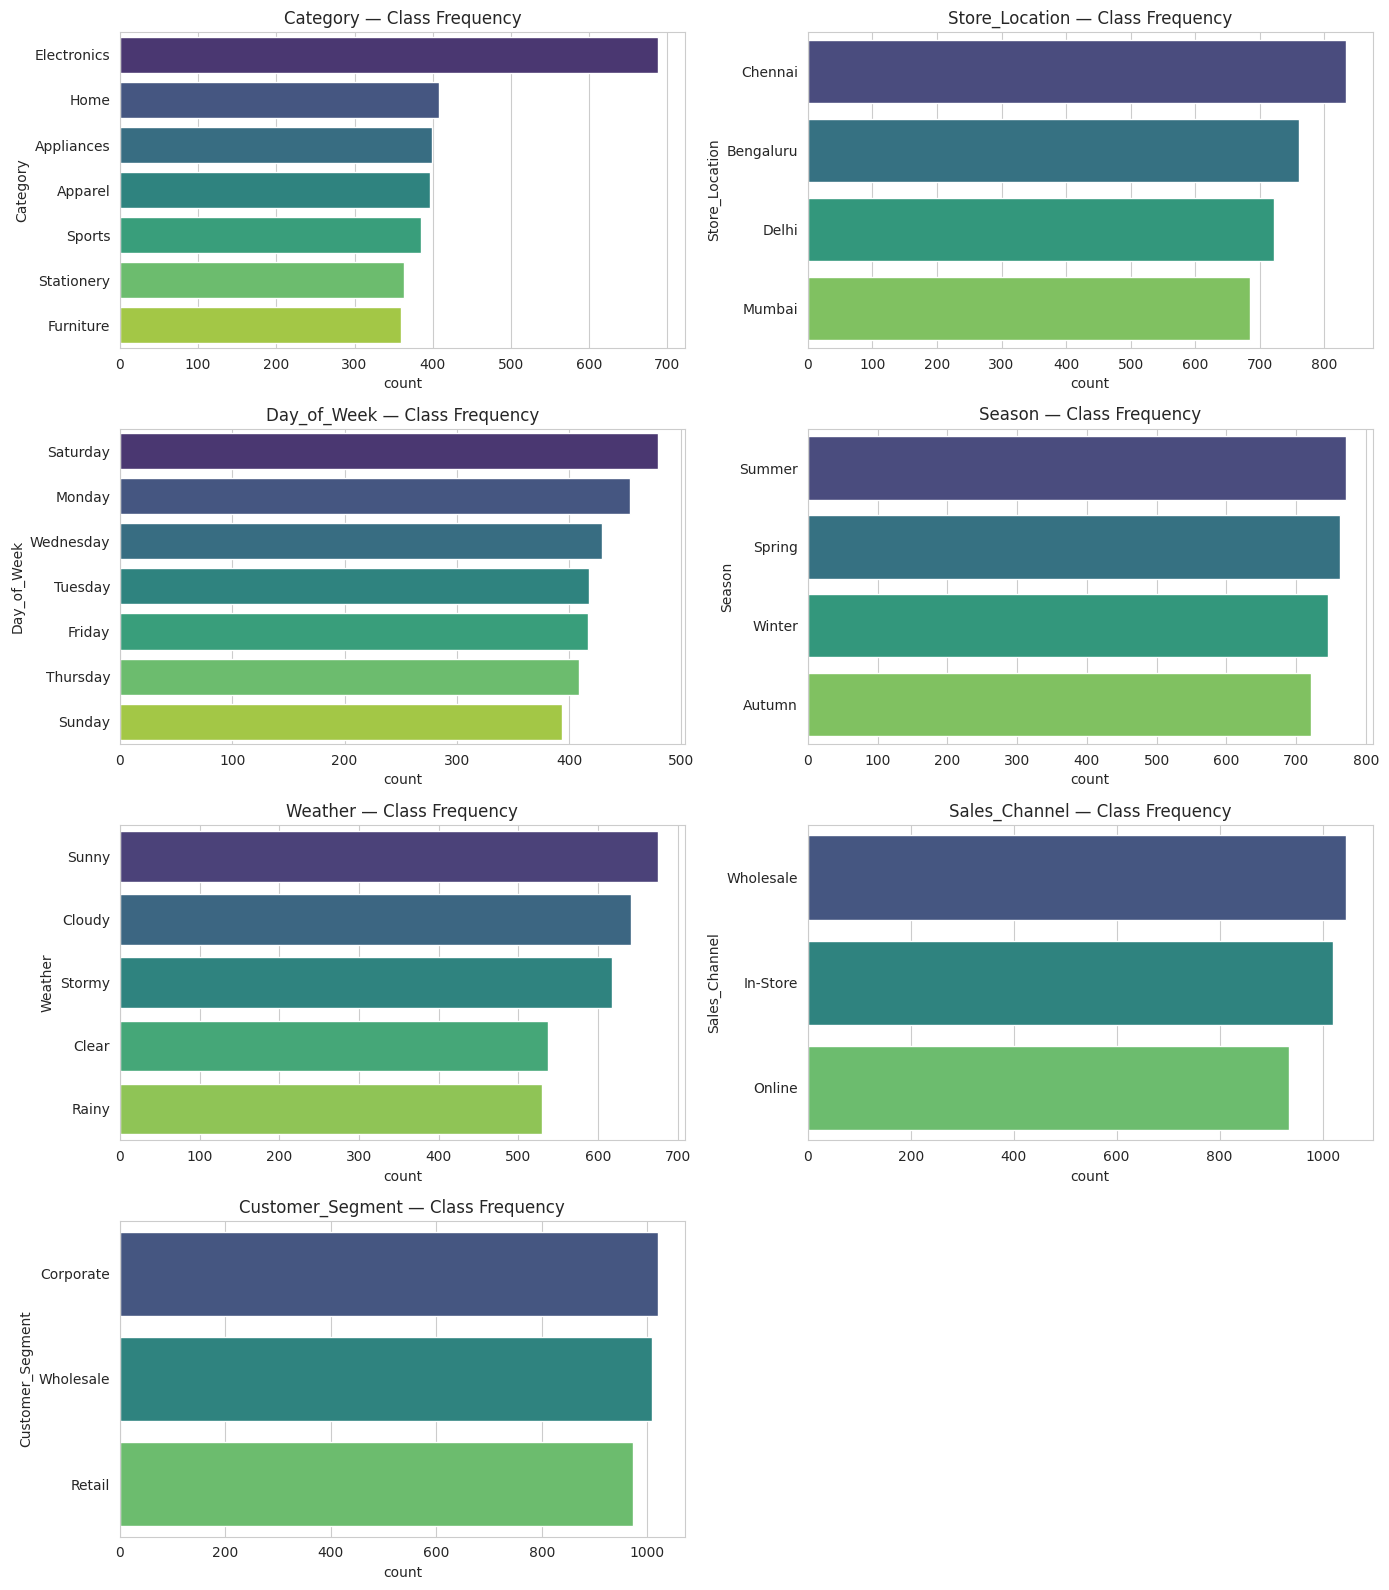

In [11]:
cat_to_plot = ['Category','Store_Location','Day_of_Week','Season','Weather','Sales_Channel','Customer_Segment']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.flatten()
for i, col in enumerate(cat_to_plot):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col} — Class Frequency')
fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


In [12]:
def iqr_bounds(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

outlier_report = {}
for col in ['Units_Sold','Revenue','Price','Marketing_Spend','Competitor_Price']:
    lo, hi = iqr_bounds(df[col])
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    outlier_report[col] = n_out

    df[col] = df[col].clip(lower=lo, upper=hi)

print('Outliers found & capped (per column):')
for k,v in outlier_report.items():
    print(f'  {k}: {v} outliers')


Outliers found & capped (per column):
  Units_Sold: 0 outliers
  Revenue: 1 outliers
  Price: 0 outliers
  Marketing_Spend: 0 outliers
  Competitor_Price: 0 outliers


In [13]:
missing_numeric = df[numeric_cols].isnull().sum()
missing_numeric = missing_numeric[missing_numeric > 0]
print('Missing (numeric):')
print(missing_numeric if len(missing_numeric) else 'None found, numeric columns are clean!')

for col in missing_numeric.index:
    df[col] = df[col].fillna(df[col].median())


Missing (numeric):
None found, numeric columns are clean!


In [14]:
print('Missing (categorical):')
print(df[categorical_cols].isnull().sum()[df[categorical_cols].isnull().sum() > 0])


df['Holiday_Name'] = df['Holiday_Name'].cat.add_categories(['No Holiday']).fillna('No Holiday')


mismatch = ((df['Holiday_Flag']==1) & (df['Holiday_Name']=='No Holiday')).sum()
print('Holiday flag/name mismatch rows:', mismatch)


Missing (categorical):
Holiday_Name    2969
dtype: int64
Holiday flag/name mismatch rows: 0


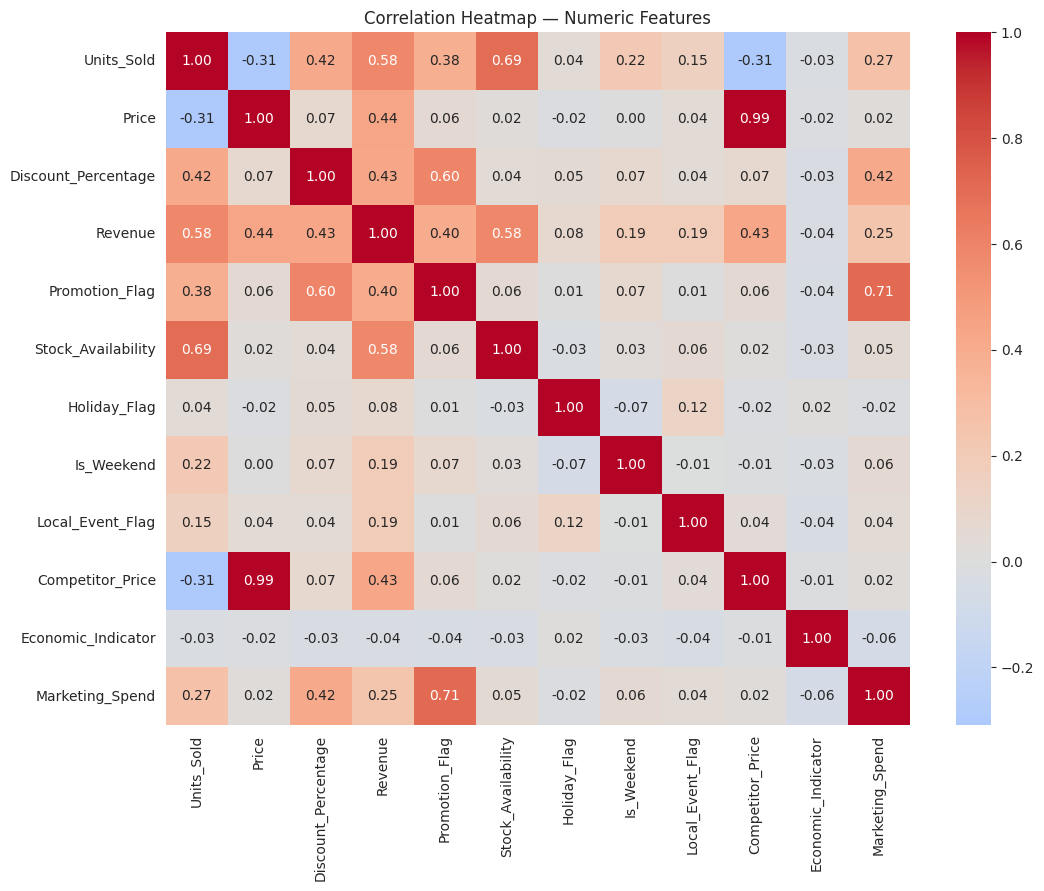

Top correlations with Units_Sold:
Units_Sold             1.000000
Stock_Availability     0.693741
Revenue                0.579453
Discount_Percentage    0.416296
Promotion_Flag         0.383766
Marketing_Spend        0.269368
Is_Weekend             0.215244
Local_Event_Flag       0.153969
Holiday_Flag           0.041688
Economic_Indicator    -0.027352
Price                 -0.306506
Competitor_Price      -0.309005
Name: Units_Sold, dtype: float64


In [15]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(12,9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Numeric Features')
plt.show()

print('Top correlations with Units_Sold:')
print(corr['Units_Sold'].sort_values(ascending=False))


In [16]:
print(df.groupby('Category')['Units_Sold'].mean().sort_values(ascending=False))
print()
pivot = df.pivot_table(values='Revenue', index='Store_Location', columns='Season', aggfunc='mean')
pivot


Category
Home           44.475490
Appliances     43.102757
Sports         43.020779
Apparel        41.874055
Stationery     41.680441
Furniture      41.297222
Electronics    40.229651
Name: Units_Sold, dtype: float64



Season,Autumn,Spring,Summer,Winter
Store_Location,,,,
Bengaluru,88644.697981,81024.327457,89241.976288,90272.221807
Chennai,83772.106319,86722.734560,90236.595223,106373.525317
Delhi,124777.104414,87955.541538,96393.838492,96327.403184
Mumbai,94728.568795,103351.054067,90162.114879,90615.087611


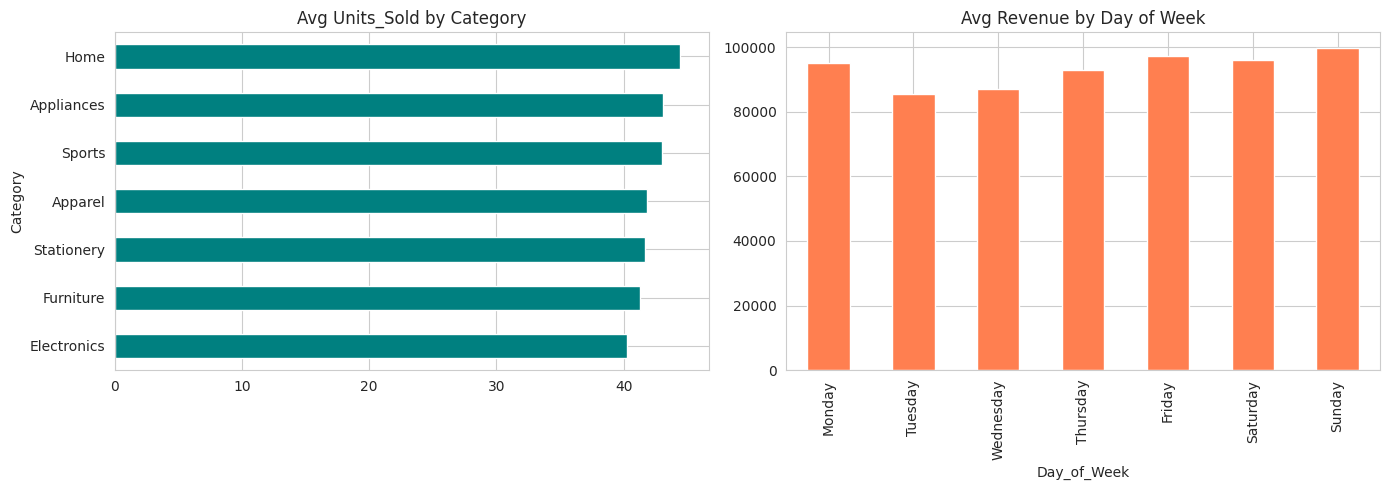

In [17]:
fig, ax = plt.subplots(1,2, figsize=(14,5))
df.groupby('Category')['Units_Sold'].mean().sort_values().plot(kind='barh', ax=ax[0], color='teal')
ax[0].set_title('Avg Units_Sold by Category')
df.groupby('Day_of_Week')['Revenue'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']).plot(kind='bar', ax=ax[1], color='coral')
ax[1].set_title('Avg Revenue by Day of Week')
plt.tight_layout()
plt.show()


Sales_Channel  In-Store  Online  Wholesale
Category                                  
Apparel             136      89        172
Appliances          148     130        121
Electronics         199     223        266
Furniture           117     115        128
Home                148     136        124
Sports              116     132        137
Stationery          156     110         97


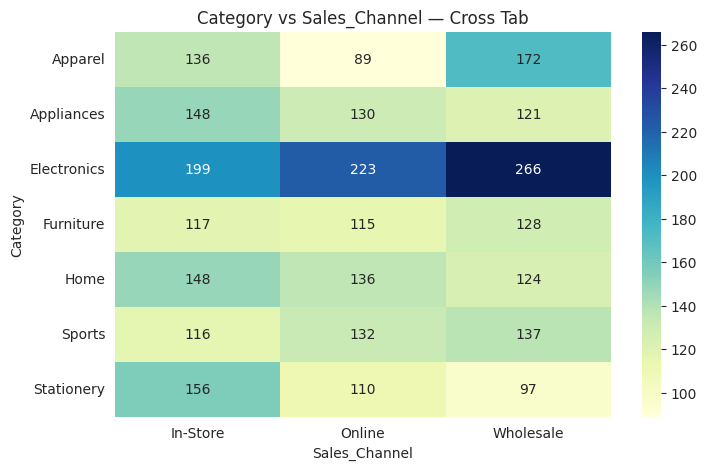

In [18]:
ct = pd.crosstab(df['Category'], df['Sales_Channel'])
print(ct)

plt.figure(figsize=(8,5))
sns.heatmap(ct, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Category vs Sales_Channel — Cross Tab')
plt.show()


   Promotion_Flag  Holiday_Flag  Units_Sold
0               0             0   23.995311
1               0             1   65.250000
2               1             0   49.179584
3               1             1   50.086957


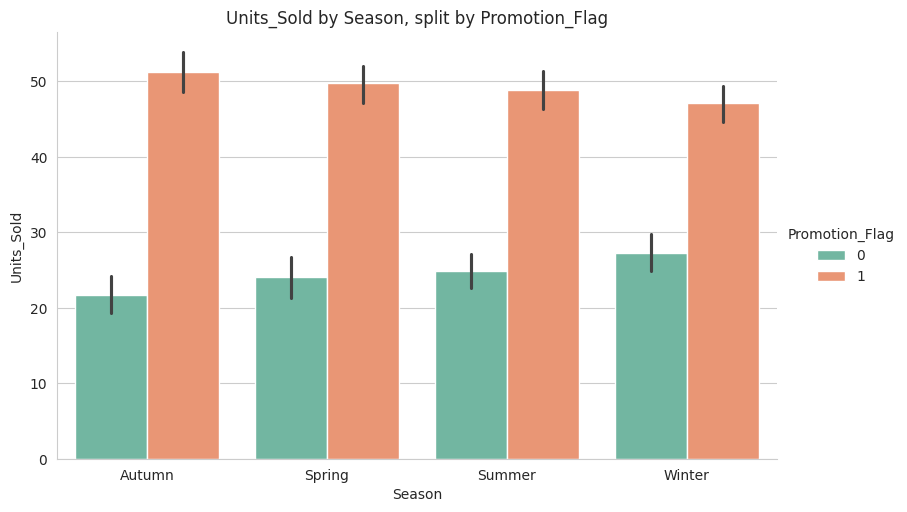

In [19]:
multi = df.groupby(['Promotion_Flag','Holiday_Flag'])['Units_Sold'].mean().reset_index()
print(multi)

sns.catplot(data=df, x='Season', y='Units_Sold', hue='Promotion_Flag', kind='bar', height=5, aspect=1.6, palette='Set2')
plt.title('Units_Sold by Season, split by Promotion_Flag')
plt.show()


In [20]:
df['Year'] = df['Date'].dt.year
df['Month_num'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['DayOfWeek_num'] = df['Date'].dt.dayofweek
df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
df['IsMonthStart'] = df['Date'].dt.is_month_start.astype(int)
df['IsMonthEnd'] = df['Date'].dt.is_month_end.astype(int)


df['month_sin'] = np.sin(2*np.pi*df['Month_num']/12)
df['month_cos'] = np.cos(2*np.pi*df['Month_num']/12)
df['dow_sin']   = np.sin(2*np.pi*df['DayOfWeek_num']/7)
df['dow_cos']   = np.cos(2*np.pi*df['DayOfWeek_num']/7)

df[['Date','Year','Month_num','WeekOfYear','month_sin','month_cos']].head()


,Date,Year,Month_num,WeekOfYear,month_sin,month_cos
0,2023-01-06,2023,1,1,0.500000,0.866025
1,2023-01-13,2023,1,2,0.500000,0.866025
2,2023-01-28,2023,1,4,0.500000,0.866025
3,2023-02-09,2023,2,6,0.866025,0.500000
4,2023-02-13,2023,2,7,0.866025,0.500000


In [21]:
df['Units_Sold_log'] = np.log1p(df['Units_Sold'])
df['Revenue_log'] = np.log1p(df['Revenue'])

print('Skew before:', df['Units_Sold'].skew().round(3), '| after log:', df['Units_Sold_log'].skew().round(3))


Skew before: 0.127 | after log: -1.174


In [22]:
df['Price_diff_vs_competitor'] = df['Price'] - df['Competitor_Price']
df['Price_ratio_vs_competitor'] = df['Price'] / df['Competitor_Price']
df['Discounted_Price'] = df['Price'] * (1 - df['Discount_Percentage']/100)
df['Revenue_per_unit'] = (df['Revenue'] / df['Units_Sold'].replace(0, np.nan)).fillna(0)
df['Marketing_efficiency'] = (df['Revenue'] / df['Marketing_Spend'].replace(0, np.nan)).fillna(0)

df[['Price_diff_vs_competitor','Discounted_Price','Revenue_per_unit']].head()


,Price_diff_vs_competitor,Discounted_Price,Revenue_per_unit
0,309.718482,3763.742294,3763.742294
1,317.182418,3763.712176,3763.712176
2,132.412285,2206.875551,2398.777773
3,-87.390805,1124.815548,1406.019435
4,236.942734,3136.982267,3337.215178


In [23]:
df['Price_bin'] = pd.qcut(df['Price'], q=3, labels=['Low','Medium','High'])
df['Discount_bin'] = pd.cut(df['Discount_Percentage'], bins=[-1,10,25,100], labels=['Low','Medium','High'])

df[['Price','Price_bin','Discount_Percentage','Discount_bin']].head()


,Price,Price_bin,Discount_Percentage,Discount_bin
0,3763.742294,High,0,Low
1,3763.712176,High,0,Low
2,2398.777773,Medium,8,Low
3,1406.019435,Low,20,Medium
4,3337.215178,Medium,6,Low


In [24]:
from sklearn.preprocessing import LabelEncoder

cat_cols_to_encode = ['Product_ID','Category','Store_ID','Store_Location','Day_of_Week','Month','Quarter',
                      'Holiday_Name','Season','Weather','Sales_Channel','Customer_Segment',
                      'Price_bin','Discount_bin']

label_encoders = {}
for c in cat_cols_to_encode:
    le = LabelEncoder()
    df[c + '_enc'] = le.fit_transform(df[c].astype(str))
    label_encoders[c] = le

print('Encoded columns created:', [c+'_enc' for c in cat_cols_to_encode])


Encoded columns created: ['Product_ID_enc', 'Category_enc', 'Store_ID_enc', 'Store_Location_enc', 'Day_of_Week_enc', 'Month_enc', 'Quarter_enc', 'Holiday_Name_enc', 'Season_enc', 'Weather_enc', 'Sales_Channel_enc', 'Customer_Segment_enc', 'Price_bin_enc', 'Discount_bin_enc']


In [25]:
df['Product_Name_word_count'] = df['Product_Name'].astype(str).apply(lambda x: len(x.split()))
df['Product_Name_length'] = df['Product_Name'].astype(str).apply(len)

df[['Product_Name','Product_Name_word_count','Product_Name_length']].drop_duplicates().head(8)


,Product_Name,Product_Name_word_count,Product_Name_length
0,Bluetooth Speaker,2,17
3,LED Desk Lamp,3,13
4,Running Shoes,2,13
6,Notebook Pack,2,13
7,Wireless Mouse,2,14
9,Yoga Mat,2,8
16,Coffee Maker,2,12
36,Office Chair,2,12


In [26]:
df['Is_High_Discount'] = (df['Discount_Percentage'] > 25).astype(int)
df['Is_Price_Above_Competitor'] = (df['Price'] > df['Competitor_Price']).astype(int)
df['Is_Low_Stock'] = (df['Stock_Availability'] == 0).astype(int)
df['Is_Peak_Season'] = df['Season'].isin(['Winter','Autumn']).astype(int)

flag_new = ['Is_High_Discount','Is_Price_Above_Competitor','Is_Low_Stock','Is_Peak_Season']
df[flag_new].sum()


,0
Is_High_Discount,0
Is_Price_Above_Competitor,1451
Is_Low_Stock,654
Is_Peak_Season,1466


## 12) Train-Test Split
Time-series problem-nala, random split pannama **date order** vechi split pannanum (last 20% = test, future simulate pandradhukku).

In [27]:
feature_cols = [
    'Price','Discount_Percentage','Promotion_Flag','Stock_Availability','Holiday_Flag',
    'Is_Weekend','Local_Event_Flag','Competitor_Price','Economic_Indicator','Marketing_Spend',
    'Year','Month_num','Day','DayOfWeek_num','WeekOfYear','IsMonthStart','IsMonthEnd',
    'month_sin','month_cos','dow_sin','dow_cos',
    'Price_diff_vs_competitor','Price_ratio_vs_competitor','Discounted_Price',
    'Revenue_per_unit','Marketing_efficiency',
    'Product_Name_word_count','Product_Name_length',
    'Is_High_Discount','Is_Price_Above_Competitor','Is_Low_Stock','Is_Peak_Season'
] + [c+'_enc' for c in cat_cols_to_encode]

target = 'Units_Sold'

df_sorted = df.sort_values('Date').reset_index(drop=True)
X = df_sorted[feature_cols]
y = df_sorted[target]

split_idx = int(len(df_sorted) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print('Train size:', X_train.shape, '| Test size:', X_test.shape)
print('Train date range:', df_sorted['Date'].iloc[0], '->', df_sorted['Date'].iloc[split_idx-1])
print('Test date range :', df_sorted['Date'].iloc[split_idx], '->', df_sorted['Date'].iloc[-1])


Train size: (2400, 46) | Test size: (600, 46)
Train date range: 2023-01-06 00:00:00 -> 2025-09-07 00:00:00
Test date range : 2025-09-08 00:00:00 -> 2026-12-25 00:00:00


In [28]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(y_true, y_pred, name=''):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    nz = y_true != 0
    mape = np.mean(np.abs((y_true[nz] - y_pred[nz]) / y_true[nz])) * 100
    smape = np.mean(2*np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-9)) * 100
    print(f'--- {name} ---')
    print(f'RMSE  : {rmse:.3f}')
    print(f'MAE   : {mae:.3f}')
    print(f'R2    : {r2:.4f}  ({r2*100:.1f}% variance explained)')
    print(f'MAPE  : {mape:.2f}%')
    print(f'SMAPE : {smape:.2f}%')
    return dict(model=name, RMSE=rmse, MAE=mae, R2=r2, MAPE=mape, SMAPE=smape)

xgb_base = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb_base.fit(X_train, y_train)
pred_base = xgb_base.predict(X_test)
results = []
results.append(evaluate(y_test.values, pred_base, 'XGBoost (baseline)'))


--- XGBoost (baseline) ---
RMSE  : 5.161
MAE   : 3.816
R2    : 0.9675  (96.7% variance explained)
MAPE  : 27.54%
SMAPE : 27.85%


In [29]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import numpy as np


y_train_log = np.log1p(y_train)

param_dist = {
    'n_estimators': [200, 400, 600, 800],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [1, 1.5, 2]
}

tscv = TimeSeriesSplit(n_splits=4)

search = RandomizedSearchCV(
    xgb.XGBRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train_log)

print('Best params:', search.best_params_)

xgb_tuned = search.best_estimator_
pred_tuned_log = xgb_tuned.predict(X_test)
pred_tuned = np.expm1(pred_tuned_log)

results.append(evaluate(y_test.values, pred_tuned, 'XGBoost (tuned)'))



Best params: {'subsample': 1.0, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 600, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
--- XGBoost (tuned) ---
RMSE  : 4.731
MAE   : 3.377
R2    : 0.9727  (97.3% variance explained)
MAPE  : 16.16%
SMAPE : 20.48%


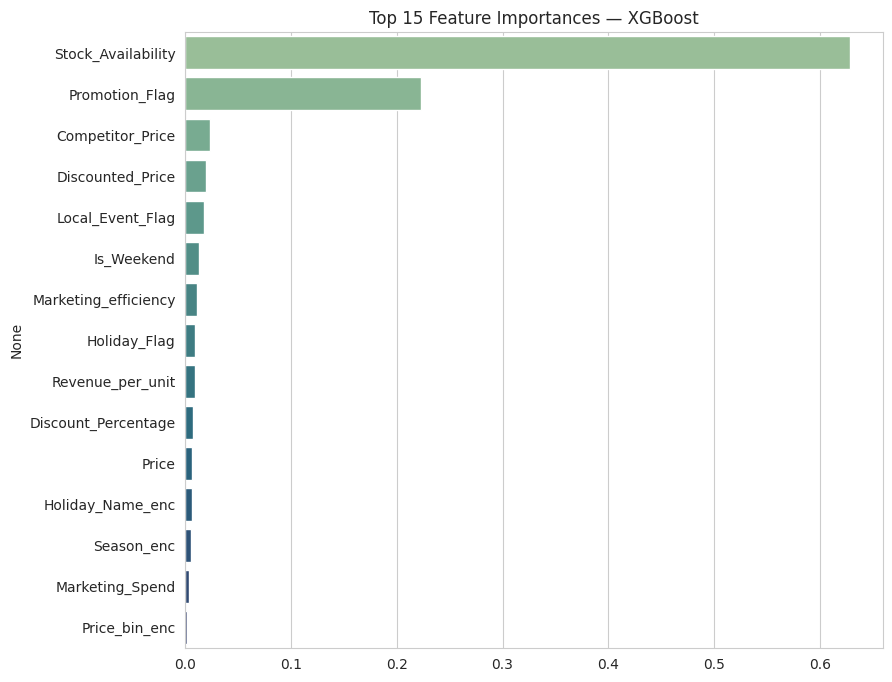

In [30]:
importances = pd.Series(xgb_tuned.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(9,8))
sns.barplot(x=importances.head(15).values, y=importances.head(15).index, palette='crest')
plt.title('Top 15 Feature Importances — XGBoost')
plt.show()


In [31]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

daily = df_sorted.groupby('Date')['Units_Sold'].sum().asfreq('D').fillna(0)
split_d = int(len(daily) * 0.8)
train_d, test_d = daily.iloc[:split_d], daily.iloc[split_d:]

sarima = SARIMAX(train_d, order=(1,1,1), seasonal_order=(1,1,1,7),
                  enforce_stationarity=False, enforce_invertibility=False)
sarima_fit = sarima.fit(disp=False)
sarima_pred = sarima_fit.forecast(steps=len(test_d))

results.append(evaluate(test_d.values, sarima_pred.values, 'SARIMA (daily total)'))


--- SARIMA (daily total) ---
RMSE  : 40.421
MAE   : 27.317
R2    : 0.0602  (6.0% variance explained)
MAPE  : 326.99%
SMAPE : 159.73%


In [32]:
from prophet import Prophet

p_train = train_d.reset_index().rename(columns={'Date':'ds','Units_Sold':'y'})
p_model = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
p_model.fit(p_train)

future = test_d.reset_index().rename(columns={'Date':'ds'})[['ds']]
p_forecast = p_model.predict(future)

results.append(evaluate(test_d.values, p_forecast['yhat'].values, 'Prophet (daily total)'))


--- Prophet (daily total) ---
RMSE  : 50.488
MAE   : 41.641
R2    : -0.4662  (-46.6% variance explained)
MAPE  : 686.33%
SMAPE : 150.57%


In [33]:
results_df = pd.DataFrame(results).set_index('model')
results_df = results_df.sort_values('RMSE')
print(results_df.round(3))

best_model_name = results_df['R2'].idxmax()
print(f'\n🏆 Best model (highest R2): {best_model_name}')


                         RMSE     MAE     R2     MAPE    SMAPE
model                                                         
XGBoost (tuned)         4.731   3.377  0.973   16.159   20.477
XGBoost (baseline)      5.161   3.816  0.967   27.544   27.853
SARIMA (daily total)   40.421  27.317  0.060  326.993  159.727
Prophet (daily total)  50.488  41.641 -0.466  686.326  150.568

🏆 Best model (highest R2): XGBoost (tuned)


In [34]:
import joblib

joblib.dump(xgb_tuned, 'best_sales_model.pkl')
joblib.dump(label_encoders, 'label_encoders.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')

print('Model & encoders saved! Colab la irundhu download pannunga:')
print(' - best_sales_model.pkl')
print(' - label_encoders.pkl')
print(' - feature_cols.pkl')



Model & encoders saved! Colab la irundhu download pannunga:
 - best_sales_model.pkl
 - label_encoders.pkl
 - feature_cols.pkl


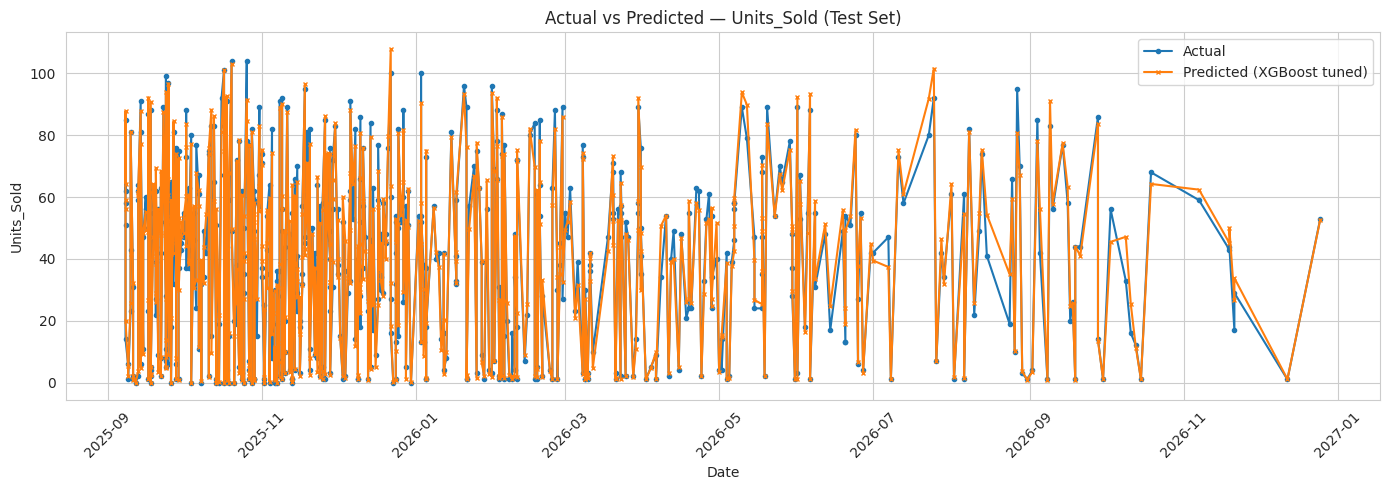

In [35]:
plt.figure(figsize=(14,5))
plt.plot(df_sorted['Date'].iloc[split_idx:].values, y_test.values, label='Actual', marker='o', markersize=3)
plt.plot(df_sorted['Date'].iloc[split_idx:].values, pred_tuned, label='Predicted (XGBoost tuned)', marker='x', markersize=3)
plt.title('Actual vs Predicted — Units_Sold (Test Set)')
plt.xlabel('Date'); plt.ylabel('Units_Sold')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [37]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
